# BEE 4750 Homework 4: Linear Programming and Capacity Expansion

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 11/06/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to analytically (or graphically) solve a linear
    program.
-   Problem 2 asks you to formulate and solve a resource allocation
    problem using linear programming.
-   Problem 3 asks you to formulate, solve, and analyze a standard
    generating capacity expansion problem.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/code/FALL 2025/BEE 4750/hw4-tas274hw4`
   Installed BenchmarkTools ─ v1.6.3
   Installed MarkdownTables ─ v1.1.0
   Installed ArgCheck ─────── v2.5.0
   Installed DataFrames ───── v1.8.1
   Installed StatsBase ────── v0.34.7
   Installed DisplayAs ────── v0.1.6
   Installed JuMP ─────────── v1.29.2
   Installed PrettyTables ─── v3.1.0
Precompiling project...
    561.2 ms  ✓ ArgCheck
    535.3 ms  ✓ StructUtils → StructUtilsTablesExt
    681.3 ms  ✓ DisplayAs
    848.3 ms  ✓ BenchmarkTools
   2100.1 ms  ✓ StatsBase
   4325.8 ms  ✓ MarkdownTables
  26917.7 ms  ✓ PrettyTables
  34046.3 ms  ✓ MathOptInterface
   2020.4 ms  ✓ MathOptIIS
  10101.3 ms  ✓ HiGHS
  18409.8 ms  ✓ JuMP
  54258.5 ms  ✓ Plots
  36511.3 ms  ✓ DataFrames
   1866.2 ms  ✓ Latexify → DataFramesExt
  14 dependencies successfully precompiled in 66 seconds. 208 already precompiled.


In [2]:
using JuMP
using HiGHS
using DataFrames
using Plots
using Measures
using CSV
using MarkdownTables

## Problems (Total: 30 Points)

### Problem 1 (Total: 3 Points)

Solve the following linear program **analytically**. Show your work and
justify any reasoning.

$$
\begin{alignedat}{2}
&& \max_{x, y} \quad & 3x + 2y\\
&&\text{subject to:} \quad & x + 4y \leq 16\\
& && x - 2y \leq -1\\
& && 0 \leq x \leq 4\\
& && 1 \leq y \leq 4.
\end{alignedat}
$$


### Problem 1 Writeup

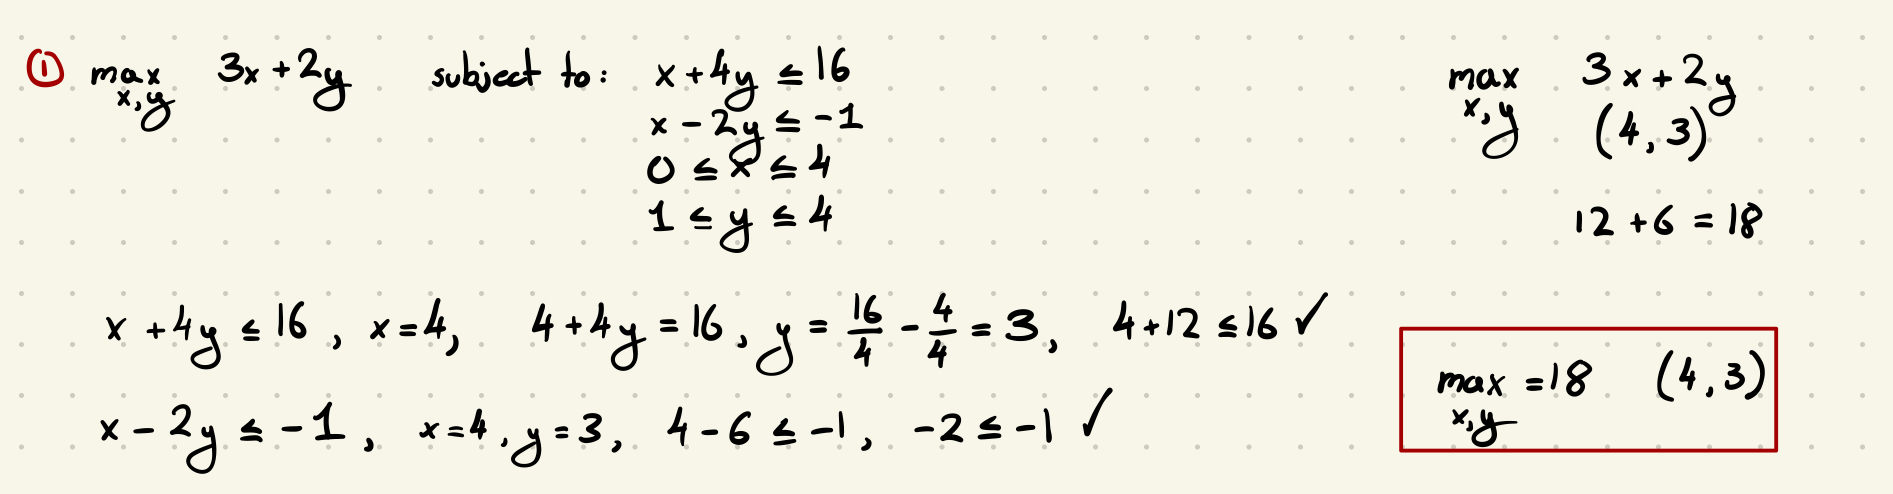

### Problem 2 (12 points)

A farmer has access to a pesticide which can be used on corn, soybeans,
and wheat fields, and costs \$70/kg-yr to apply. The crop yields the
farmer can obtain following crop yields by applying varying rates of
pesticides to the field are shown in
<a href="#tbl-yields" class="quarto-xref">Table 1</a>.

| Application Rate (kg/ha) | Soybean (kg/ha) | Wheat (kg/ha) | Corn (kg/ha) |
|:------------------------:|:---------------:|:-------------:|:------------:|
|            0             |      2900       |     3500      |     5900     |
|            1             |      3800       |     4100      |     6700     |
|            2             |      4400       |     4200      |     7900     |

Table 1: Crop yields from applying varying pesticide rates for Problem
1.

The costs of production, *excluding pesticides*, for each crop, and
selling prices, are shown in
<a href="#tbl-costs" class="quarto-xref">Table 2</a>.

|   Crop   | Production Cost (\$/ha-yr) | Selling Price (\$/kg) |
|:--------:|:--------------------------:|:---------------------:|
| Soybeans |            350             |         0.36          |
|  Wheat   |            280             |         0.27          |
|   Corn   |            390             |         0.22          |

Table 2: Costs of crop production, excluding pesticides, and selling
prices for each crop.

Recently, environmental authorities have declared that farms cannot have
an *average* application rate on soybeans, wheat, and corn which exceeds
0.8, 0.7, and 0.6 kg/ha, respectively. The farmer has asked you for
advice on how they should plant crops and apply pesticides to maximize
profits over 130 total ha while remaining in regulatory compliance if
demand for each crop (which is the maximum the market would buy) this
year is 250,000 kg?


#### Problem 2.1

Formulate a linear program for this resource allocation problem,
including clear definitions of decision variable(s) (including units),
objective function(s), and constraint(s) (make sure to explain functions
and constraints with any needed derivations and explanations). **Tip:
Make sure that all of your constraints are linear**.

In [ ]:
crops = [:soy, :wheat, :corn]
rates = [0, 1, 2]

yield = Dict(
    (:soy,0)=>2900.0, (:soy,1)=>3800.0, (:soy,2)=>4400.0,
    (:wheat,0)=>3500.0, (:wheat,1)=>4100.0, (:wheat,2)=>4200.0,
    (:corn,0)=>5900.0,  (:corn,1)=>6700.0,  (:corn,2)=>7900.0
)

prod_cost = Dict(:soy=>350.0, :wheat=>280.0, :corn=>390.0)   # $/ha-yr
price     = Dict(:soy=>0.36,  :wheat=>0.27,  :corn=>0.22)    # $/kg
rate_cap  = Dict(:soy=>0.8,   :wheat=>0.7,   :corn=>0.6)     # kg/ha
demand    = Dict(:soy=>250_000.0, :wheat=>250_000.0, :corn=>250_000.0) # kg
land_total = 140.0
pesticide_cost_per_kg = 70.0

model = Model(HiGHS.Optimizer)

# Decision Variables
@variable(model, A[c in crops, r in rates] >= 0)

# Objective Function
@objective(model, Max, sum(price[c]*yield[(c,r)]*A[c,r] - prod_cost[c]*A[c,r] - pesticide_cost_per_kg*r*A[c,r] for c in crops, r in rates))

# Land limit
@constraint(model, sum(A[c,r] for c in crops, r in rates) <= land_total)

# Demand limits
@constraint(model, [c in crops], sum(yield[(c,r)]*A[c,r] for r in rates) <= demand[c])

# Average-Rate Caps
@constraint(model, [c in crops], sum(r*A[c,r] for r in rates) <= rate_cap[c]*sum(A[c,r] for r in rates))

optimize!(model)

println("Status: ", termination_status(model))
println("Optimal profit: \$", round(objective_value(model); digits=2))
println("Nonzero allocations (crop, rate kg/ha, ha):")
for c in crops, r in rates
    a = value(A[c,r])
    if a > 1e-6
        println("  ", c, ", r=", r, " => ", round(a; digits=4), " ha")
    end
end

Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7 rows; 9 cols; 27 nonzeros
Coefficient ranges:
  Matrix [2e-01, 8e+03]
  Cost   [7e+02, 1e+03]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 2e+05]
Presolving model
7 rows, 9 cols, 27 nonzeros  0s
7 rows, 9 cols, 27 nonzeros  0s
Presolve : Reductions: rows 7(-0); columns 9(-0); elements 27(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.8170298458e+02 Ph1: 7(28.3601); Du: 9(181.703) 0s
          7     1.2403516702e+05 Pr: 0(0) 0s
Model status        : Optimal
Simplex   iterations: 7
Objective value     :  1.2403516702e+05
P-D objective error :  5.8660204673e-17
HiGHS run time      :          0.00
Status: OPTIMAL
Optimal profit: $124035.17
Nonzero allocations (crop, rate kg/ha, ha):
  soy, r=0 => 13.8122 ha
  soy, r=1 => 55.2486 ha
  wheat, r=0 => 9.7433 ha
 

#### Problem 2.1 Writeup



#### Problem 2.2

How many ha should the farmer dedicate to each crop and with what
pesticide application rate(s)? How much profit will the farmer expect to
make?

#### Problem 2.2 Writeup
The optimal ha for the farmer to dedicate to each crop with pesticide application rates are as follows:
| Application Rate (kg/ha) | Soybean (ha) | Wheat (ha) | Corn (ha) |
|:------------------------:|:---------------:|:-------------:|:------------:|
|            0             |      13.81       |     6.74      |     26.92     |
|            1             |        55.24     |      15.73     |    0      |
|            2             |          0   |       0    |     11.53     |

The profit that the farmer should expect from this is $116,741.17

#### Problem 2.3

The farmer has an opportunity to buy an extra 10 ha of land. How much
extra profit would this land be worth to the farmer? Discuss why this
value makes sense and under what conditions you would recommend the
farmer should make the purchase.

#### Problem 2.3
With an extra +10 ha of land the profit changes to $124,035.17, this is an increase of $7,294. This means that there is an increase in profits of $729.40 /ha. This slight increase makes sense, as 

It would be worth buying this land if the cost of maintaining this land per hectare of the land is less then $729.40 ha. 

### Problem 3 (15 points)

For this problem, we will use hourly load (demand) data from 2013 in New
York’s Zone C (which includes Ithaca). The load data is loaded and
plotted below in <a href="#fig-demand" class="quarto-xref">Figure 1</a>.

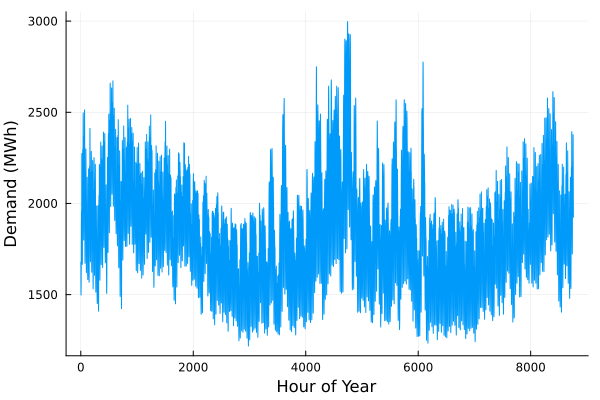

In [12]:
# load the data, pull Zone C, and reformat the DataFrame
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, :"Time Stamp" => :Date)
demand = NY_demand[:, [:Date, :C]]
rename!(demand, :C => :Demand)
demand[:, :Hour] = 1:nrow(demand)

# plot demand
plot(demand.Hour, demand.Demand, xlabel="Hour of Year", ylabel="Demand (MWh)", label=:false)

Next, we load the generator data, shown in
<a href="#tbl-generators" class="quarto-xref">Table 3</a>. This data
includes fixed costs (\$/MW installed), variable costs (\$/MWh
generated), and CO<sub>2</sub> emissions intensity (tCO<sub>2</sub>/MWh
generated).

In [13]:
gens = DataFrame(CSV.File("data/generators.csv"))

Row,Plant,FixedCost,VarCost,Emissions
,String15,Int64,Int64,Float64
1,Geothermal,450000,0,0.0
2,Coal,220000,24,1.0
3,NG CCGT,82000,30,0.43
4,NG CT,65000,40,0.55
5,Wind,91000,0,0.0
6,Solar,70000,0,0.0


Finally, we load the hourly solar and wind capacity factors, which are
plotted in <a href="#fig-cf" class="quarto-xref">Figure 2</a>. These
tell us the fraction of installed capacity which is expected to be
available in a given hour for generation (typically based on the average
meteorology).

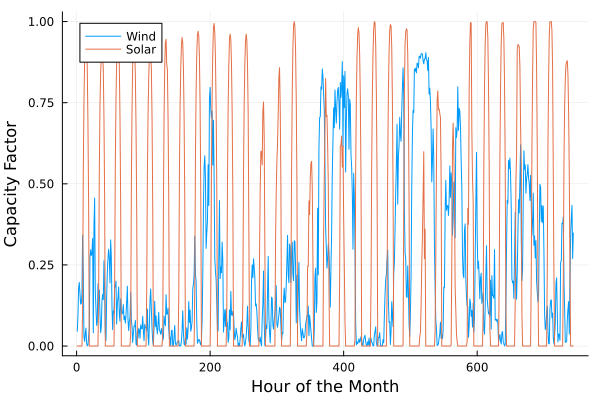

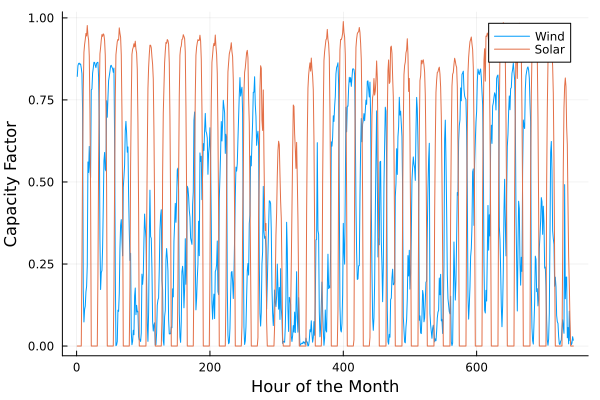

In [14]:
# load capacify factors into a DataFrame
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))

# plot January capacity factors
p1 = plot(cap_factor.Wind[1:(24*31)], label="Wind")
plot!(cap_factor.Solar[1:(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

p2 = plot(cap_factor.Wind[4344:4344+(24*31)], label="Wind")
plot!(cap_factor.Solar[4344:4344+(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

display(p1)
display(p2)

You have been asked to develop a generating capacity expansion plan for
the utility in Riley County, NY, which currently has no existing
electrical generation infrastructure. The utility can build any of the
following plant types: geothermal, coal, natural gas combined cycle gas
turbine (CCGT), natural gas combustion turbine (CT), solar, and wind.
The NY state legislature is planning to enact an annual CO<sub>2</sub>
limit, which for the utility would limit the emissions in its footprint
to 1.5 MtCO<sub>2</sub>/yr.

While coal, CCGT, and CT plants can generate at their full installed
capacity, geothermal plants operate at maximum 85% capacity, and solar
and wind available capacities vary by the hour depend on the expected
meteorology. The utility will also penalize any non-served demand at a
rate of \$10,000/MWh.

#### Problem 3.1

Formulate a linear program for this capacity expansion problem,
including clear definitions of decision variable(s) (including units),
objective function(s), and constraint(s) (make sure to explain functions
and constraints with any needed derivations and explanations).

In [ ]:
using CSV, DataFrames
using JuMP, HiGHS

NY_demand       = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
generators      = DataFrame(CSV.File("data/generators.csv"))
capacity_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))
rename!(NY_demand, "Time Stamp" => :Date)
demand = NY_demand[:, [:Date, :C]]
rename!(demand, :C => :Demand)
demand.Hour = 1:nrow(demand)
H = collect(1:nrow(demand))
D = Float64.(demand.Demand)

gens = generators
rename!(gens,
    "Plant"      => :tech,
    "FixedCost"  => :fix_cost_per_MWyr,
    "VarCost"    => :var_cost_per_MWh,
    "Emissions"  => :co2_t_per_MWh
)

gens.tech = Symbol.(lowercase.(string.(gens.tech)))
generators = collect(gens.tech)

# Our parameters
F = Dict(gens.tech .=> Float64.(gens.fix_cost_per_MWyr))   # $/MW-yr
c = Dict(gens.tech .=> Float64.(gens.var_cost_per_MWh))    # $/MWh
e = Dict(gens.tech .=> Float64.(gens.co2_t_per_MWh))       # tCO₂/MWh

# Capacity Factor
CF = Dict{Symbol, Vector{Float64}}()
# This sets the capacity factors for each generator type
for g in generators
    if g == :wind
        CF[g] = Float64.(capacity_factor.Wind[H])
    elseif g == :solar
        CF[g] = Float64.(capacity_factor.Solar[H])
    elseif g == :geothermal
        CF[g] = fill(0.85, length(H))
    else
        CF[g] = fill(1.0, length(H))
    end
end

# Emissions Constraint
E_max   = 1.5e6       # +1_000.00           # tCO₂/yr cap

# Penalty for unserved energy
P       = 10_000.0    # $/MWh penalty

# List of generators that emit CO2
emitters = [g for g in generators if e[g] > 0.0]


# Initialize the model
model = Model(HiGHS.Optimizer)

# Decision Variagles
@variable(model, K[g in generators] >= 0)               # MW
@variable(model, x[g in generators, h in H] >= 0)       # MWh
@variable(model, s[h in H] >= 0)                        # MWh unserved

# Objective Function
@objective(model, Min,
    # Total Cost
    sum(F[g] * K[g] for g in generators) +
    # Variable Cost
    sum(c[g] * x[g,h] for g in generators, h in H) +
    # Penalty
    sum(P * s[h] for h in H)
)

# Demand balance
@constraint(model, [h in H], sum(x[g,h] for g in generators) + s[h] == D[h])
# Generator limits
@constraint(model, [g in generators, h in H], x[g,h] <= CF[g][h] * K[g])
# Emissions constraint
@constraint(model, sum(e[g] * sum(x[g,h] for h in H) for g in emitters) <= E_max)
optimize!(model)


Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 61321 rows; 61326 cols; 188256 nonzeros
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+06]
Presolving model
56857 rows, 56862 cols, 179328 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
56857 rows, 56862 cols, 179328 nonzeros  0s
Presolve : Reductions: rows 56857(-4464); columns 56862(-4464); elements 179328(-8928)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(5.18855e+06) 0s
      24264     6.5231296320e+08 Pr: 13571(1.34502e+06); Du: 0(1.0619e-07) 5s
      30075     7.7615642227e+08 Pr: 1919(139011); Du: 0(7.07015e-08) 10s
      32698     7.8535295894e+08 Pr: 0(0); Du: 0(4.

#### Problem 3.1 Writeup

The decision variables for the problem are,
$$K_g\geq0~(MW) \text{,  installed capacity of technology }g$$
$$x_{g,h}\geq0~(MWh)\text{, generation by g in hours h}$$
$$s_h\geq0~(MWh)\text{, unserved demand in hour h}$$
The objective function is to minimize the total annual system cost,
$$\text{min~}Z=\sum\limits_{g}F_gK_g+\sum\limits_h\sum\limits_gc_gx_{g,h}+\sum\limits_h{Ps_h}$$
The first term consists of, $F_g$ is the annualized fixed cost of building and maintaining 1 MW of capacity of generator g. $K_g$ is how many MW of that generator we decide to make. Therefore this is the capital cost.

The second term consists of, $c_g$, the variable cost to generate 1 MWh of electricity from the type of generator g. $x_{g,h}$ is the energy produced by that generator in a given hour h. Therefore this is the hourly production cost

The third term consists of $P$ which is the penalty of any non-served demand at 10,000 MWh, and $s_h$ is the unmet demand in hours $h$. Therefore this is the penalty for unserved demand.

The constraints are as follows,

The hourly supply and demand balance,
$$\sum\limits_g{x_{g,h}+s_h=D_h}$$
Where for every hour, the total electricity generated plus and non-served demand must equal the total demand, note this is for $[1,8760]$ hours.

The available capacity,
$$x_{g,h}\leq{CF_{g,h}}K_g$$
Where for each type of energy generator in an hour can only produce as much as its available capacity factor. Its capacity factor, $CF_{g,h}$ multiplied by its installed capacity $K_g$. For each type of energy generator its limited by its own constraint. For wind and solar they are limited by the hourly solar or wind resource, as the sun is not always shining and the wind is not always blowing. For geothermal it has a capacity factor of 0.85. For Coal, CCGT, and CT, the capacity factor is always 1.0. 

The annual emissions cap,
$$\sum\limits_{h=1}^{8760}\sum\limits_{g\{\text{coal,ccgt,ct}\}}e_gx_{g,h}\leq{E_{max}}$$
where $E_{max}=1.5\cdot{10^6}$ tCO/yr. The total emissions produced over the year by fossil fuel plants, cannot exceed 1.5 million tonnes of CO2. $e_g$ is the emissions intensity of the energy generator, tCO2/MWh. 

A non-negative constraint,
$$K_g\geq{0},~~x_{g,h}\geq{0},~~s_h\geq{0}$$
As we can't have a negative capacity, negative generation, or negative unserved demand



#### Problem 3.2

How much should the utility build of each type of generating plant? What
will the total cost be? How much energy will be non-served?

In [ ]:
# Problem 3.2 Code
K_star = DataFrame(tech = String.(generators), capacity_MW = [value(K[g]) for g in generators])
sort!(K_star, :capacity_MW, rev=true)
Z_total = objective_value(model)
total_shed_MWh = sum(value.(s[h]) for h in H)

# Results
println("Built capacity by plant type (MW):")
for r in eachrow(K_star)
    @printf("  %-10s : %.3f \n", r.tech, r.capacity_MW)
end
@printf("\nTotal annual system cost (dollars): %.2f\n", Z_total)
@printf("Total non-served energy (MWh): %.2f\n", total_shed_MWh)

Built capacity by plant type (MW):
  wind       : 2548.888 
  solar      : 2103.749 
  ng ccgt    : 1509.173 
  ng ct      : 703.062 
  geothermal : 285.568 
  coal       : 0.000 

Total annual system cost (dollars): 785352958.94
Total non-served energy (MWh): 332.29


#### Problem 3.2 Writeup

How much should the utility build of each type of generating plant? What
will the total cost be? How much energy will be non-served?


The utility should build the total capacity of each type of generating plant as follows (MW):
- Wind,          2548.888
- Solar,         2103.749
- NG CCGT,       1509.173
- NG CT,         703.062
- Geothermal,    285.568
- Coal,          0

The total cost will be $785,352,958.94.

The amount of energy that will be non-served is 332.29 Mwh

#### Problem 3.3

What fraction of annual generation does each plant type produce? How
does this compare to the breakdown of built capacity that you found in
Problem 3.2? Do these results make sense given the demand and generator
data?


In [39]:
# Code for Problem 3.3
total_gen = sum(gen_df.gen_MWh)
gen_df[:, :fraction_gen] = gen_df.gen_MWh ./ total_gen
gen_df[:, :fraction_cap] = K_star.capacity_MW ./ sum(K_star.capacity_MW)

6-element Vector{Float64}:
 0.3564658739728441
 0.2942125703076335
 0.21106013375921312
 0.0983242815428723
 0.03993714041743699
 0.0

#### Problem 3.3 Writeup

The fraction of annual generation for each plant type is as follows,
- Wind,          35.6%
- Solar,         29.4%
- NG CCGT,       21.1%
- NG CT,         9.8%
- Geothermal,    3.99%
- Coal,          0

How does this compare to the breakdown of built capacity that you found in
Problem 3.2? Do these results make sense given the demand and generator
data?

Compared to the built capacity data in problem 3.2, the percentages match and make sense with regard to the demand/data, Wind and Solar make up the largest share of capacity and generation, but because they have low capacity factors, they require more installed MW. Natural-gas and geothermal have lower percentages and smaller built-capacity shares, yet have a good portion as they are able to run more hours and reliably. Coal is not used at all due to its high emissions constrained by the cap. 


#### Problem 3.4

Make a plot of the electricity price in each hour. Discuss any trends
that you see.

DON'T DO THIS

#### Problem 3.5

What is the shadow price of CO<sub>2</sub>? What is the value to the
utility be of allowing it to emit an additional 1000 tCO<sub>2</sub>/yr?


In [ ]:
# Code for Problem 3.5

emissions_baseline_cost = 785_352_958.94
emissions_plus1000_cost = 785_170_187.01
drop    = emissions_baseline_cost - emissions_plus1000_cost
shadow  = drop / 1000.0
println("Shadow price of emissions constraint (dollars/tCO2): ", shadow)

Shadow price of emissions constraint (dollars/tCO2): 182.77193000006676


#### Problem 3.5 Writeup

We can calculate the shadow price of CO2 by comparing the price between two different runs. It was found that the shadow price of CO2 is $182.77 / tCO2

When we allow +1,000 tCO2/yr, we save an annual cost of $182,772, the value of the utility becomes $785,170,187.01


> **Significant Digits**
>
> Use `round(x; digits=n)` to report values to the appropriate
> precision! If your number is on a different order of magnitude and you
> want to round to a certain number of significant digits, you can use
> `round(x; sigdigits=n)`.

> **Getting Variable Output Values**
>
> `value.(x)` will report the values of a `JuMP` variable `x`, but it
> will return a special container which holds other information about
> `x` that is useful for `JuMP`. This means that you can’t use this
> output directly for further calculations. To just extract the values,
> use `value.(x).data`.

> **Suppressing Model Command Output**
>
> The output of specifying model components (variable or constraints)
> can be quite large for this problem because of the number of time
> periods. If you end a cell with an `@variable` or `@constraint`
> command, I *highly* recommend suppressing output by adding a
> semi-colon after the last command, or you might find that your
> notebook crashes.

## References

List any external references consulted, including classmates.